In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import least_squares

In [5]:
!pwd

/Users/mablin/Projects/github.com/DelftMercurians/dies/notebooks


In [16]:
# Pack/unpack: 7 strictly positive params → log-space for unconstrained opt.
PARAM_NAMES = ["tau_fwd", "tau_str", "amax_fwd", "amax_str",
                "stic_fwd", "stic_str", "v_eps"]

def predict_vel_next(theta, t, cmd, heading, vel):
    """Vectorised one-step prediction. theta is log-space (length 7)."""
    p = np.exp(theta)
    tau, a_max, stic = p[0:2], p[2:4], p[4:6]
    v_eps = p[6]

    dt = np.diff(t)                              # (N-1,)
    h = heading[:-1]
    c, s = np.cos(h), np.sin(h)
    # body-frame command and velocity at sample i
    vx, vy = vel[:-1, 0], vel[:-1, 1]
    cx, cy = cmd[:-1, 0], cmd[:-1, 1]
    v_b   = np.stack([ c*vx + s*vy, -s*vx + c*vy], axis=-1)
    cmd_b = np.stack([ c*cx + s*cy, -s*cx + c*cy], axis=-1)

    err = cmd_b - v_b
    arg_acc = err / (tau * a_max)                # broadcasts (N-1, 2)
    accel = a_max * np.tanh(arg_acc) - stic * np.tanh(v_b / v_eps)

    # back to global, Euler integrate
    ax = c*accel[:, 0] - s*accel[:, 1]
    ay = s*accel[:, 0] + c*accel[:, 1]
    vx_pred = vx + ax * dt
    vy_pred = vy + ay * dt
    return np.stack([vx_pred, vy_pred], axis=-1)

def residuals(theta, t, cmd, heading, vel):
    pred = predict_vel_next(theta, t, cmd, heading, vel)
    obs = vel[1:]
    return (obs - pred).ravel()

def fit(csv_path, init=None):
    df = pd.read_csv(csv_path).sort_values("t").reset_index(drop=True)
    # drop consecutive duplicate states (world tracker idle ticks)
    keep = np.ones(len(df), dtype=bool)
    for col in ["pos_x", "pos_y", "vel_x", "vel_y"]:
        keep[1:] &= df[col].diff().fillna(1).to_numpy()[1:] != 0
    df = df[keep].reset_index(drop=True)

    t = df["t"].to_numpy()
    cmd = df[["cmd_x", "cmd_y"]].to_numpy()
    heading = df["heading"].to_numpy()
    vel = df[["vel_x", "vel_y"]].to_numpy()

    if init is None:
        init = np.array([0.08, 0.10, 6000.0, 4500.0, 150.0, 200.0, 30.0])
    theta0 = np.log(init)

    res = least_squares(
        residuals, theta0,
        args=(t, cmd, heading, vel),
        method="lm", xtol=1e-10, ftol=1e-10, max_nfev=2000,
    )
    p = np.exp(res.x)
    pred = predict_vel_next(res.x, t, cmd, heading, vel)
    err = vel[1:] - pred
    rms = np.sqrt((err**2).mean(axis=0))

    return dict(zip(PARAM_NAMES, p)), rms, res

params, rms, res = fit("../.dies/recordings/square_1777133935714.csv")
for k, v in params.items():
    print(f"{k:12s} = {v:.4g}")
print(f"rms (vx, vy) = {rms[0]:.2f}, {rms[1]:.2f} mm/s")
print(f"converged={res.success}, nfev={res.nfev}, cost={res.cost:.3g}")

tau_fwd      = 0.6376
tau_str      = 1.145
amax_fwd     = 2.79e+10
amax_str     = 296.1
stic_fwd     = 135.2
stic_str     = 123.8
v_eps        = 0.04906
rms (vx, vy) = 74.77, 60.09 mm/s
converged=True, nfev=92, cost=8.88e+05


In [17]:
import matplotlib.pyplot as plt

def load_recording(csv_path):
    """Load CSV, dedupe stalled tracker frames, add body-frame v/cmd and
    numerical body-frame acceleration (forward diff)."""
    df = pd.read_csv(csv_path).sort_values("t").reset_index(drop=True)
    keep = np.ones(len(df), dtype=bool)
    for col in ["pos_x", "pos_y", "vel_x", "vel_y"]:
        keep[1:] &= df[col].diff().fillna(1).to_numpy()[1:] != 0
    df = df[keep].reset_index(drop=True)

    h = df["heading"].to_numpy()
    c, s = np.cos(h), np.sin(h)
    df["v_fwd"]  =  c * df["vel_x"] + s * df["vel_y"]
    df["v_str"]  = -s * df["vel_x"] + c * df["vel_y"]
    df["c_fwd"]  =  c * df["cmd_x"] + s * df["cmd_y"]
    df["c_str"]  = -s * df["cmd_x"] + c * df["cmd_y"]

    dt = df["t"].diff()
    df["a_fwd"] = df["v_fwd"].diff() / dt
    df["a_str"] = df["v_str"].diff() / dt
    return df

def model_accel(v, cmd, tau, a_max, stic, v_eps):
    """One-axis body-frame accel from the dies-mpc dynamics model."""
    err = cmd - v
    return a_max * np.tanh(err / (tau * a_max)) - stic * np.tanh(v / v_eps)

def axis_params(params, axis):
    """Pull (tau, a_max, stic, v_eps) for 'fwd' or 'str' from a fit dict."""
    return (params[f"tau_{axis}"], params[f"amax_{axis}"],
            params[f"stic_{axis}"], params["v_eps"])

REC_PATH = "../.dies/recordings/square_1777133935714.csv"
df = load_recording(REC_PATH)
print(f"{len(df)} samples after dedupe, t = {df['t'].iloc[0]:.2f} → {df['t'].iloc[-1]:.2f} s")

194 samples after dedupe, t = 127.48 → 148.13 s


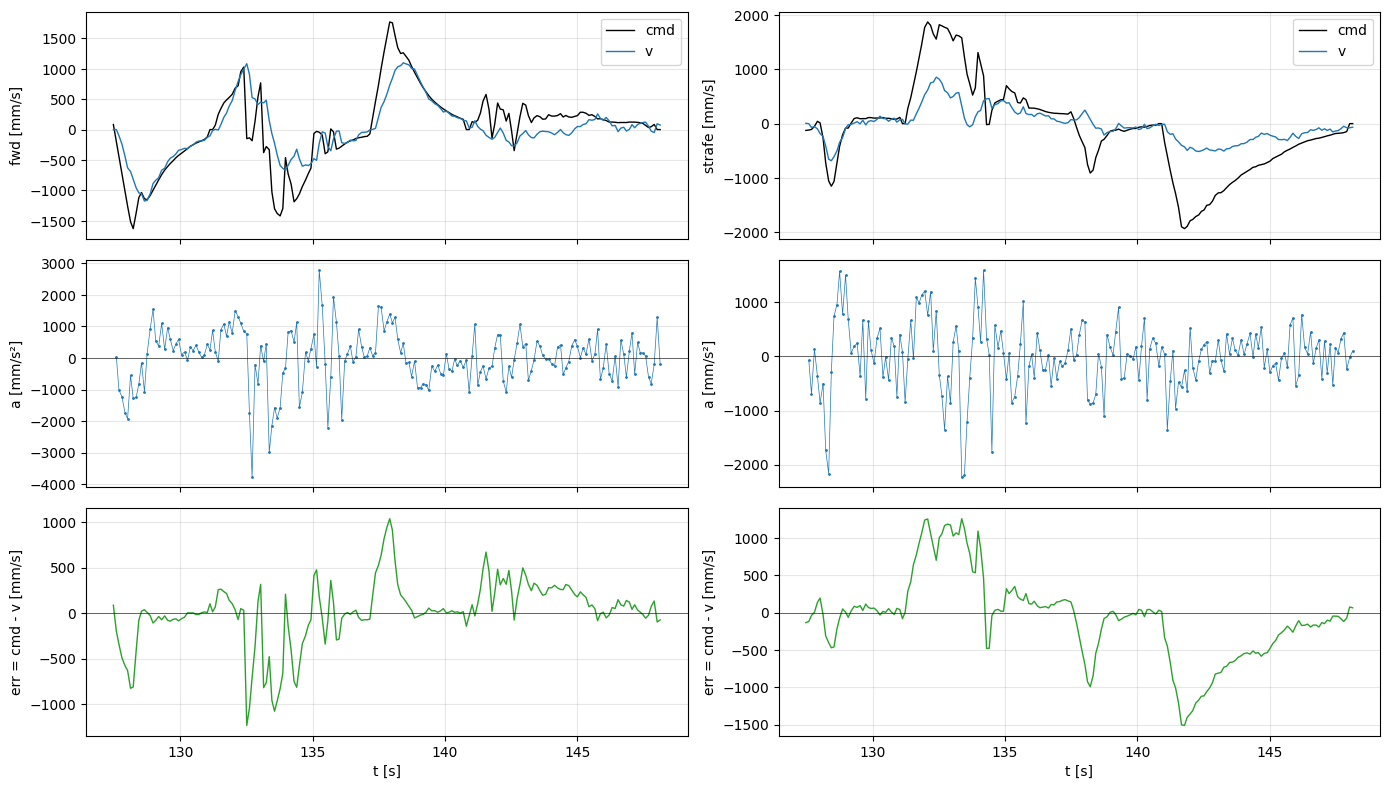

In [18]:
# Per-axis time series: cmd vs v, accel, error.
fig, axes = plt.subplots(3, 2, figsize=(14, 8), sharex=True)
for col, (axis, vcol, ccol, acol) in enumerate([
    ("fwd",    "v_fwd", "c_fwd", "a_fwd"),
    ("strafe", "v_str", "c_str", "a_str"),
]):
    axes[0, col].plot(df["t"], df[ccol], "k-",  lw=1, label="cmd")
    axes[0, col].plot(df["t"], df[vcol], "C0-", lw=1, label="v")
    axes[0, col].set_ylabel(f"{axis} [mm/s]")
    axes[0, col].legend(loc="upper right")
    axes[0, col].grid(alpha=0.3)

    axes[1, col].plot(df["t"], df[acol], ".-", ms=2, lw=0.5)
    axes[1, col].axhline(0, color="k", lw=0.4)
    axes[1, col].set_ylabel(f"a [mm/s²]")
    axes[1, col].grid(alpha=0.3)

    axes[2, col].plot(df["t"], df[ccol] - df[vcol], "C2-", lw=1)
    axes[2, col].axhline(0, color="k", lw=0.4)
    axes[2, col].set_ylabel("err = cmd - v [mm/s]")
    axes[2, col].set_xlabel("t [s]")
    axes[2, col].grid(alpha=0.3)
fig.tight_layout()

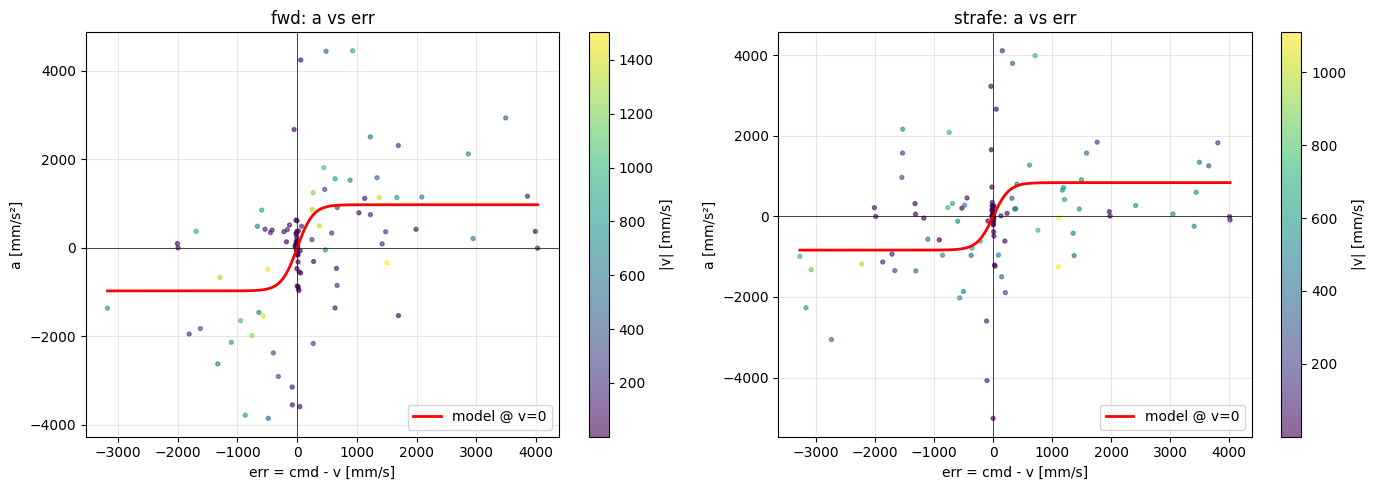

In [14]:
# a vs err scatter with the fitted-model curve overlaid.
# - Color encodes |v|; the model curve is a slice at v=0.
# - With a good fit the cloud should follow the red curve, with vertical
#   spread explained by the v-dependent stiction term.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (axis, vcol, ccol, acol) in zip(axes, [
    ("fwd",    "v_fwd", "c_fwd", "a_fwd"),
    ("strafe", "v_str", "c_str", "a_str"),
]):
    err = (df[ccol] - df[vcol]).to_numpy()
    a   = df[acol].to_numpy()
    v   = df[vcol].to_numpy()
    mask = np.isfinite(err) & np.isfinite(a)

    sc = ax.scatter(err[mask], a[mask], c=np.abs(v[mask]),
                    cmap="viridis", s=8, alpha=0.6)
    plt.colorbar(sc, ax=ax, label="|v| [mm/s]")

    tau, a_max, stic, v_eps = axis_params(params, axis if axis == "fwd" else "str")
    err_grid = np.linspace(np.nanmin(err), np.nanmax(err), 400)
    ax.plot(err_grid, model_accel(0.0, err_grid, tau, a_max, stic, v_eps),
            "r-", lw=2, label="model @ v=0")

    ax.axhline(0, color="k", lw=0.5)
    ax.axvline(0, color="k", lw=0.5)
    ax.set_xlabel("err = cmd - v [mm/s]")
    ax.set_ylabel("a [mm/s²]")
    ax.set_title(f"{axis}: a vs err")
    ax.legend(loc="lower right")
    ax.grid(alpha=0.3)
fig.tight_layout()

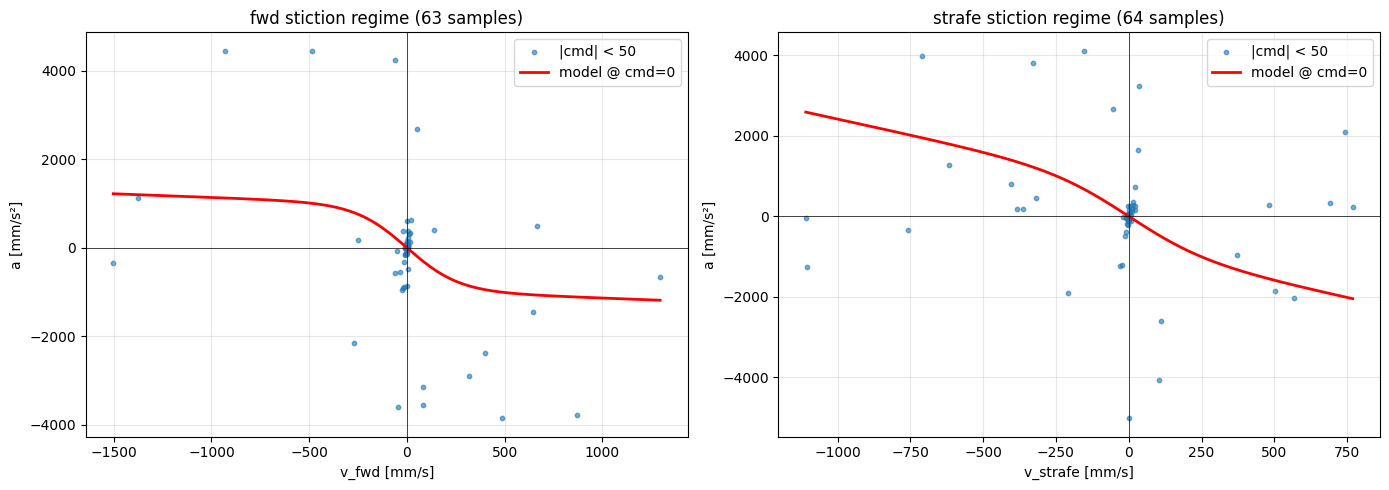

In [15]:
# Stiction view: a vs v at near-zero command. With cmd ≈ 0 the accel term
# drops out, leaving a ≈ −stiction · tanh(v / v_eps). Cloud should be a
# clean S-curve through the origin if the model captures stiction correctly.
CMD_NEAR_ZERO = 50.0   # mm/s, "near zero" body-frame command threshold
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (axis, vcol, ccol, acol) in zip(axes, [
    ("fwd",    "v_fwd", "c_fwd", "a_fwd"),
    ("strafe", "v_str", "c_str", "a_str"),
]):
    sel = df[df[ccol].abs() < CMD_NEAR_ZERO]
    ax.scatter(sel[vcol], sel[acol], s=10, alpha=0.6, label=f"|cmd| < {CMD_NEAR_ZERO:.0f}")

    tau, a_max, stic, v_eps = axis_params(params, axis if axis == "fwd" else "str")
    v_grid = np.linspace(sel[vcol].min(), sel[vcol].max(), 400) if len(sel) else np.linspace(-200, 200, 400)
    ax.plot(v_grid, model_accel(v_grid, 0.0, tau, a_max, stic, v_eps),
            "r-", lw=2, label="model @ cmd=0")

    ax.axhline(0, color="k", lw=0.5)
    ax.axvline(0, color="k", lw=0.5)
    ax.set_xlabel(f"v_{axis} [mm/s]")
    ax.set_ylabel("a [mm/s²]")
    ax.set_title(f"{axis} stiction regime ({len(sel)} samples)")
    ax.legend(loc="upper right")
    ax.grid(alpha=0.3)
fig.tight_layout()